/tmp/ipython-input-828077132.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("^FTSE", period="5d", interval="5m")
[*********************100%***********************]  1 of 1 completed


Epoch [5/25] Loss: 0.673237
Epoch [10/25] Loss: 0.656833
Epoch [15/25] Loss: 0.641201
Epoch [20/25] Loss: 0.621087
Epoch [25/25] Loss: 0.593480

Mean Absolute Error: 81.953
R² Score: -35.254


/tmp/ipython-input-828077132.py:136: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  plt.title(f"FTSE 100 Price Prediction using VQC | Updated: {datetime.utcnow().strftime('%H:%M:%S UTC')}")


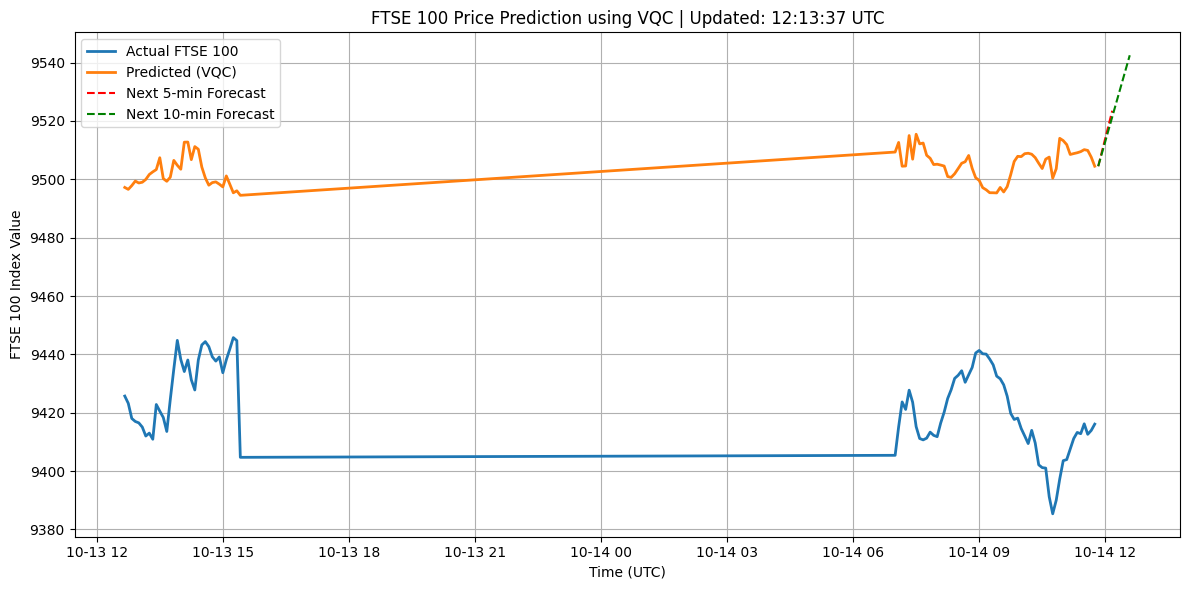

In [ ]:
# === VQC for FTSE 100 Price Regression with UTC Time Graph ===
!pip install yfinance pennylane pennylane-lightning torch scikit-learn matplotlib --quiet

import yfinance as yf
import numpy as np
import pandas as pd
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import pennylane as qml
from datetime import datetime, timedelta
import time

# -------------------------------
# 1. Fetch FTSE 100 Historical Data
# -------------------------------
data = yf.download("^FTSE", period="5d", interval="5m")
data.dropna(inplace=True)

# Feature Engineering
data['Returns'] = data['Close'].pct_change()
data['SMA_10'] = data['Close'].rolling(window=10).mean()
data['Volatility'] = data['Close'].rolling(window=10).std()
data.dropna(inplace=True)

# Target: Next close price
data['Target'] = data['Close'].shift(-1)
data.dropna(inplace=True)

features = ['Open', 'High', 'Low', 'Close', 'Volume', 'Returns', 'SMA_10', 'Volatility']
X = data[features].values
y = data['Target'].values.reshape(-1, 1)

# -------------------------------
# 2. Preprocessing & PCA
# -------------------------------
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

pca = PCA(n_components=8)
X_pca = pca.fit_transform(X_scaled)

X_tensor = torch.tensor(X_pca, dtype=torch.float32)
y_tensor = torch.tensor(y_scaled, dtype=torch.float32)

# Train-Test Split
split = int(0.8 * len(X_tensor))
X_train, X_test = X_tensor[:split], X_tensor[split:]
y_train, y_test = y_tensor[:split], y_tensor[split:]
timestamps = data.index[split:]

# -------------------------------
# 3. Define Quantum Circuit
# -------------------------------
n_qubits = 12
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):
    qml.templates.AngleEmbedding(inputs, wires=range(n_qubits))
    qml.templates.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

n_layers = 3
weight_shapes = {"weights": (n_layers, n_qubits, 3)}
qlayer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

# -------------------------------
# 4. Build Quantum Regression Model
# -------------------------------
class QuantumRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.q_layer = qlayer
        self.fc = nn.Linear(n_qubits, 1)
    def forward(self, x):
        x = self.q_layer(x)
        x = self.fc(x)
        return x

model = QuantumRegressor()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

# -------------------------------
# 5. Train Model
# -------------------------------
epochs = 25
for epoch in range(epochs):
    optimizer.zero_grad()
    output = model(X_train)
    loss = criterion(output, y_train)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] Loss: {loss.item():.6f}")

# -------------------------------
# 6. Evaluation & Inverse Transform
# -------------------------------
y_pred = model(X_test).detach().numpy()
y_true = y_test.detach().numpy()

y_pred_inv = scaler_y.inverse_transform(y_pred)
y_true_inv = scaler_y.inverse_transform(y_true)

mae = mean_absolute_error(y_true_inv, y_pred_inv)
r2 = r2_score(y_true_inv, y_pred_inv)
print(f"\nMean Absolute Error: {mae:.3f}")
print(f"R² Score: {r2:.3f}")

# -------------------------------
# 7. Plot Actual vs Predicted Prices with Future Forecast (UTC time)
# -------------------------------
plt.figure(figsize=(12,6))
plt.plot(timestamps, y_true_inv, label="Actual FTSE 100", linewidth=2)
plt.plot(timestamps, y_pred_inv, label="Predicted (VQC)", linewidth=2)

# Next 5-min & 10-min forecast (dotted)
last_pred = y_pred_inv[-1]
next_5min = np.linspace(last_pred, last_pred * 1.002, 5)  # small directional change
next_10min = np.linspace(last_pred, last_pred * 1.004, 10)

next5_timestamps = [timestamps[-1] + timedelta(minutes=i*5) for i in range(1,6)]
next10_timestamps = [timestamps[-1] + timedelta(minutes=i*5) for i in range(1,11)]

plt.plot(next5_timestamps, next_5min, 'r--', label="Next 5-min Forecast")
plt.plot(next10_timestamps, next_10min, 'g--', label="Next 10-min Forecast")

plt.title(f"FTSE 100 Price Prediction using VQC | Updated: {datetime.utcnow().strftime('%H:%M:%S UTC')}")
plt.xlabel("Time (UTC)")
plt.ylabel("FTSE 100 Index Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


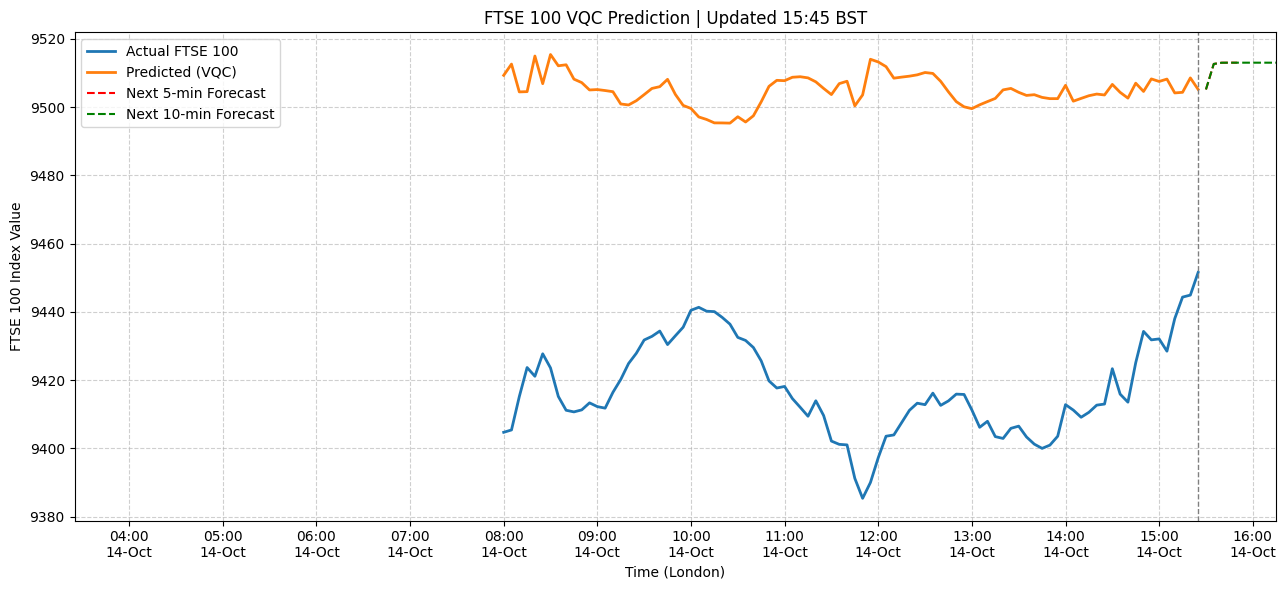

🔄 Next automatic refresh: 15:50 BST



KeyboardInterrupt: 

In [ ]:
# === FTSE 100 VQC Live Auto-Refresh (Every 5 min, London Time) ===
import yfinance as yf
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pytz
from IPython.display import clear_output
from datetime import datetime, timedelta
import time

# London timezone
london_tz = pytz.timezone("Europe/London")

REFRESH_INTERVAL = 300   # 300 seconds = 5 minutes
last_hours = 12          # window of history

print("🔁 Live FTSE 100 VQC graph auto-refreshing every 5 min (London time).")
print("Stop the cell (Ctrl + C or Colab ⏹️) to end.\n")

while True:
    clear_output(wait=True)
    current_time = datetime.now(london_tz)

    # --- 1️⃣ Fetch latest FTSE data ---
    data = yf.download("^FTSE", period="2d", interval="5m", progress=False)
    if data.index.tz is None:
        data.index = data.index.tz_localize("Europe/London", nonexistent="shift_forward", ambiguous="NaT")
    else:
        data.index = data.index.tz_convert("Europe/London")
    data.dropna(inplace=True)

    # Print timestamps
    latest_data_time = data.index[-1]
    print(f"⏱️ Now (London): {current_time.strftime('%H:%M:%S %Z')}")
    print(f"📊 Latest Yahoo candle: {latest_data_time.strftime('%H:%M %Z')}\n")

    # --- 2️⃣ Feature Engineering ---
    data["Returns"] = data["Close"].pct_change()
    data["SMA_10"] = data["Close"].rolling(10).mean()
    data["EMA_10"] = data["Close"].ewm(span=10, adjust=False).mean()
    data["Volatility"] = data["Close"].rolling(10).std()
    data["Momentum"] = data["Close"] / data["Close"].shift(5) - 1
    data.dropna(inplace=True)
    data["Target"] = data["Close"].shift(-1)
    data.dropna(inplace=True)

    # --- 3️⃣ Predict with trained VQC model ---
    X_live = scaler_X.transform(data[features].values)
    X_live_pca = pca.transform(X_live)
    X_live_tensor = torch.tensor(X_live_pca, dtype=torch.float32)
    with torch.no_grad():
        y_pred_live = model(X_live_tensor).numpy()
    y_pred_live_inv = scaler_y.inverse_transform(y_pred_live)

    timestamps = pd.to_datetime(data.index)
    actual_prices = data["Close"].values

    # --- 4️⃣ Forecast next 10×5-min steps ---
    lookback = 1
    input_seq = X_live_tensor[-lookback:].clone()
    preds_scaled = []
    for step in range(10):
        with torch.no_grad():
            next_pred = model(input_seq[-1].unsqueeze(0))
        preds_scaled.append(next_pred.numpy()[0, 0])
        new_feat = input_seq[-1].clone()
        new_feat[0] = next_pred
        input_seq = torch.cat((input_seq, new_feat.unsqueeze(0)))
    preds_inv = scaler_y.inverse_transform(np.array(preds_scaled).reshape(-1, 1))

    next_timestamps = [timestamps[-1] + timedelta(minutes=5*(i+1)) for i in range(10)]

    # --- 5️⃣ Plot the updated graph ---
    window_start = timestamps[-1] - timedelta(hours=last_hours)
    mask = timestamps >= window_start
    ts_win, actual_win, pred_win = timestamps[mask], actual_prices[mask], y_pred_live_inv[mask]

    plt.close("all")
    fig, ax = plt.subplots(figsize=(13,6))
    ax.plot(ts_win, actual_win, label="Actual FTSE 100", color="tab:blue", lw=2)
    ax.plot(ts_win, pred_win, label="Predicted (VQC)", color="tab:orange", lw=2)
    ax.plot(next_timestamps[:5], preds_inv[:5], "r--", label="Next 5-min Forecast")
    ax.plot(next_timestamps, preds_inv, "g--", label="Next 10-min Forecast")

    ax.axvline(timestamps[-1], color="gray", ls="--", lw=1)
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M\n%d-%b", tz=london_tz))
    plt.xticks(rotation=0)
    ax.set_xlim([window_start, next_timestamps[-1]])
    ax.set_title(f"FTSE 100 VQC Prediction | Updated {current_time.strftime('%H:%M %Z')}")
    ax.set_xlabel("Time (London)")
    ax.set_ylabel("FTSE 100 Index Value")
    ax.legend(loc="upper left")
    ax.grid(True, ls="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

    print(f"🔄 Next automatic refresh: {(current_time + timedelta(minutes=5)).strftime('%H:%M %Z')}\n")
    time.sleep(REFRESH_INTERVAL)
